# Categorical Encoding 

Real-world datasets rarely arrive in a form that machine learning algorithms can directly consume. One of the most pervasive challenges is the presence of **categorical variables** — features whose values are discrete labels (e.g., city names, product types, employment status) rather than numbers. Since virtually all ML algorithms operate on numerical inputs, transforming these labels into meaningful numerical representations is a critical and non-trivial preprocessing step.

A naive or poorly chosen encoding strategy can silently corrupt model training by introducing **false ordinal relationships**, causing **information loss**, or leaking **target information** from the test set into the training process. Conversely, a well-chosen encoding can be a decisive factor in model performance.

In this notebook, we study three encoding strategies implemented in `ifri_mini_ml_lib` — **Label Encoding**, **Frequency Encoding**, and **Target Encoding** — examining their mathematical foundations, algorithmic behavior, computational performance relative to `scikit-learn`, and the practical trade-offs that guide their use.

## 1. Key Concepts

### 1.1 Problem Formulation

Let $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$ be a dataset of $N$ samples, where $\mathbf{x}_i \in \mathcal{X}$ is a feature vector containing at least one categorical column $X^{(j)}$ taking values in a finite set of categories $\mathcal{C} = \{c_1, c_2, \dots, c_K\}$, and $y_i \in \mathcal{Y}$ is the associated target.

The goal of categorical encoding is to define an injective mapping:

$$\phi: \mathcal{C} \rightarrow \mathbb{R}$$

such that replacing each category $c_k$ with its encoded value $\phi(c_k)$ yields a numerical representation that is **informative**, **consistent**, and **compatible** with the downstream learning algorithm.

Different encoding strategies define $\phi$ differently, and the optimal choice depends on:
- The **cardinality** $K = |\mathcal{C}|$ of the feature
- Whether the task is **supervised** (has access to $y$) or **unsupervised**
- The **learning algorithm** (e.g., tree-based vs. linear models)
- The **risk of data leakage** in the pipeline

## 2. Encoding Techniques

### 2.1 Label Encoding

**Label encoding** is the simplest form of categorical encoding. It assigns a distinct integer index to each category observed in the training data. Given $K$ unique categories $\{c_1, c_2, \dots, c_K\}$ discovered in the order of their first appearance, the mapping is:

$$\phi_{\text{label}}(c_k) = k - 1, \quad k \in \{1, 2, \dots, K\}$$

**Properties:**
- *Time complexity*: $O(N)$ for fit and transform
- *Space complexity*: $O(K)$ for the mapping dictionary
- *Output dimensionality*: unchanged (1 column in, 1 column out)

> **When to use**: Label encoding is well-suited for **tree-based models** (Decision Trees, Random Forests, Gradient Boosting) that split on thresholds and do not interpret integer order as magnitude. It should be **avoided for linear models** and neural networks, as these algorithms will incorrectly infer an ordinal structure.

### 2.2 Frequency Encoding

**Frequency encoding** replaces each category with its *relative frequency* — the proportion of times it appears in the dataset. For a category $c_k$ observed $n_k$ times across $N$ total samples:

$$\phi_{\text{freq}}(c_k) = \frac{n_k}{N}, \quad \sum_{k=1}^{K} \phi_{\text{freq}}(c_k) = 1$$

This encoding is **unsupervised** (does not require the target $y$) and carries distributional information about how common each category is. Rare categories receive small values; dominant categories receive large values.

**Properties:**
- *Output range*: $(0, 1]$
- *Output dimensionality*: unchanged
- *Risk*: **Frequency collision** — two distinct categories $c_i \neq c_j$ with $n_i = n_j$ will receive identical encoded values, making them indistinguishable to any model.

> **When to use**: Frequency encoding is an excellent default for **high-cardinality** features (e.g., zip codes, product IDs) and is compatible with **any algorithm**. It is particularly effective when the frequency of a category is itself predictive.

### 2.3 Target Encoding

**Target encoding** (also known as *mean encoding*) is a **supervised** technique that replaces each category with the conditional mean of the target variable $y$ over all training samples belonging to that category.

Formally, let $\mathcal{I}_k = \{i \in [N] : x_i^{(j)} = c_k\}$ be the set of training indices whose $j$-th feature equals $c_k$. The encoding is:

$$\phi_{\text{target}}(c_k) = \mathbb{E}[y \mid X^{(j)} = c_k] \approx \frac{1}{|\mathcal{I}_k|} \sum_{i \in \mathcal{I}_k} y_i$$

A **smoothed** variant mitigates overfitting for rare categories by blending the category mean with the global mean $\bar{y}$:

$$\phi_{\text{smooth}}(c_k) = \frac{n_k \cdot \bar{y}_k + \lambda \cdot \bar{y}}{n_k + \lambda}$$

where $\lambda > 0$ is a smoothing parameter and $\bar{y} = \frac{1}{N}\sum_{i=1}^{N} y_i$ is the global target mean.

**Properties:**
- *Requires*: target variable $y$ at fit time
- *Output range*: $[\min(y), \max(y)]$
- *Risk*: **Data leakage** — must be fit exclusively on training data

> **When to use**: Target encoding delivers strong performance for **high-cardinality supervised tasks**. Always fit on training data only and prefer smoothed variants in production pipelines.

### 2.4 Summary Table

| Technique | Supervised | Output Range | Best For | Key Risk |
|---|---|---|---|---|
| **Label** | No | $[0, K-1]$ | Tree-based models, low cardinality | False ordinality |
| **Frequency** | No | $(0, 1]$ | Any algorithm, high cardinality | Frequency collision |
| **Target** | Yes | $[\min y, \max y]$ | High cardinality, supervised | Data leakage |

## 3. Pseudo-algorithm

The `CategoricalEncoder` class follows a standard scikit-learn-compatible `fit` / `transform` API.

---

**`fit(X, y=None)`** — *Learn the encoding mapping from training data*

1. $\mathcal{F} \leftarrow$ set of categorical columns in $X$
2. **for each** column $j \in \mathcal{F}$ **do**
3. $\quad \mathcal{C}^{(j)} \leftarrow$ unique values of $X^{(j)}$
4. $\quad$ **if** Label Encoding: $\quad \phi^{(j)}(c_k) \leftarrow k-1$ for each $c_k \in \mathcal{C}^{(j)}$
5. $\quad$ **if** Frequency Encoding: $\quad \phi^{(j)}(c_k) \leftarrow n_k^{(j)} / N$ for each $c_k$
6. $\quad$ **if** Target Encoding: $\quad \phi^{(j)}(c_k) \leftarrow \text{mean}(\{y_i : x_i^{(j)} = c_k\})$ for each $c_k$
7. $\quad$ Store $\phi^{(j)}$ in `self.mapping[j]`
8. **end for**

---

**`transform(X)`** — *Apply the learned mapping to new data*

1. $\tilde{X} \leftarrow X.\text{copy}()$
2. **for each** column $j \in \mathcal{F}$ **do**
3. $\quad \tilde{X}^{(j)} \leftarrow \tilde{X}^{(j)}.\text{map}(\phi^{(j)})$ using `self.mapping[j]`
4. **end for**
5. **return** $\tilde{X}$

---

> **Key design principle**: `fit()` only *learns* — it never modifies the data. `transform()` only *applies* — it never updates the mapping. This separation ensures the encoder can be safely applied to unseen test data without recomputing statistics from it.

## 4. Implementation & Benchmarking

We benchmark the `CategoricalEncoder` from `ifri_mini_ml_lib` against equivalent implementations from `scikit-learn` on a synthetic dataset of **5,000 samples** with **2 categorical columns** of varying cardinality and **1 numerical column**. Each encoding is timed over **20 repetitions** to obtain a stable average execution time.

### 4.1 Dataset Construction

In [46]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Import CategoricalEncoder from ifri_mini_ml_lib ───────────
from ifri_mini_ml_lib.preprocessing.preparation import CategoricalEncoder

# ── Reproducibility ───────────────────────────────────────────
np.random.seed(0)
n        = 5000
reps     = 20
cat_cols = ['A', 'B']

# Column A: low cardinality (5 categories)
# Column B: high cardinality (20 city labels)
cats_A   = np.random.choice(['alpha', 'beta', 'gamma', 'delta', 'epsilon'], n)
cats_B   = np.random.choice([f'city_{i}' for i in range(20)], n)
X_big    = pd.DataFrame({'A': cats_A, 'B': cats_B, 'num': np.random.randn(n)})
y_big    = pd.DataFrame({'target': np.random.randint(0, 2, n)})
y_series = y_big['target']

print(f"Dataset shape : {X_big.shape}")
print(f"Cardinality   : A={X_big['A'].nunique()} | B={X_big['B'].nunique()}")
print(f"Repetitions   : {reps}")
X_big.head(3)

Dataset shape : (5000, 3)
Cardinality   : A=5 | B=20
Repetitions   : 20


,A,B,num
0,epsilon,city_8,0.181234
1,alpha,city_1,1.397424
2,delta,city_15,-0.154458


### 4.2 Benchmarking — `ifri-mini-ml-lib`

In [47]:
# ── Define encoders with their respective y arguments ─────────
encoders_ifri = {
    'label'    : (CategoricalEncoder('label'),                          None ),
    'frequency': (CategoricalEncoder('frequency'),                      None ),
    'target'   : (CategoricalEncoder('target', target_column='target'), y_big),
}

timings_ifri = {}

for name, (enc, y_arg) in encoders_ifri.items():
    t0 = time.perf_counter()
    for _ in range(reps):
        enc.fit_transform(X_big, y=y_arg)
    timings_ifri[name] = (time.perf_counter() - t0) / reps * 1000  # convert to ms

print("ifri-mini-ml-lib timings (ms):")
for k, v in timings_ifri.items():
    print(f"  {k:<12}: {v:.3f} ms")

ifri-mini-ml-lib timings (ms):
  label       : 4.150 ms
  frequency   : 3.951 ms
  target      : 5.261 ms


### 4.3 Benchmarking — `scikit-learn`

In [48]:
from sklearn.preprocessing import LabelEncoder

timings_sklearn = {}

# ── Label Encoding ────────────────────────────────────────────
t0 = time.perf_counter()
for _ in range(reps):
    X_tmp = X_big.copy()
    for col in cat_cols:
        le = LabelEncoder()
        X_tmp[col] = le.fit_transform(X_tmp[col])
timings_sklearn['label'] = (time.perf_counter() - t0) / reps * 1000

# ── Frequency Encoding (no native sklearn class — pandas baseline) ──
t0 = time.perf_counter()
for _ in range(reps):
    X_tmp = X_big.copy()
    for col in cat_cols:
        freq = X_tmp[col].value_counts(normalize=True)
        X_tmp[col] = X_tmp[col].map(freq)
timings_sklearn['frequency'] = (time.perf_counter() - t0) / reps * 1000

# ── Target Encoding (sklearn >= 1.3) or manual groupby fallback ──
try:
    from sklearn.preprocessing import TargetEncoder
    t0 = time.perf_counter()
    for _ in range(reps):
        te = TargetEncoder(target_type='binary')
        te.fit_transform(X_big[cat_cols], y_series)
    timings_sklearn['target'] = (time.perf_counter() - t0) / reps * 1000
except ImportError:
    # Manual groupby mean — equivalent to basic target encoding
    t0 = time.perf_counter()
    for _ in range(reps):
        X_tmp = X_big.copy()
        X_tmp['target'] = y_series.values
        for col in cat_cols:
            means = X_tmp.groupby(col)['target'].mean()
            X_tmp[col] = X_tmp[col].map(means)
        X_tmp.drop('target', axis=1, inplace=True)
    timings_sklearn['target'] = (time.perf_counter() - t0) / reps * 1000

print("scikit-learn timings (ms):")
for k, v in timings_sklearn.items():
    print(f"  {k:<12}: {v:.3f} ms")

scikit-learn timings (ms):
  label       : 3.029 ms
  frequency   : 3.066 ms
  target      : 7.287 ms


### 4.4 Results

In [49]:
# ── Build comparison table ────────────────────────────────────
results = pd.DataFrame({
    'Encoding'              : list(timings_ifri.keys()),
    'ifri-mini-ml-lib (ms)' : [round(v, 3) for v in timings_ifri.values()],
    'scikit-learn (ms)'     : [round(v, 3) for v in timings_sklearn.values()],
    'Speedup (x)'           : [
        round(timings_sklearn[k] / timings_ifri[k], 2)
        for k in timings_ifri
    ],
    'Winner': [
        'ifri     ' if timings_ifri[k] < timings_sklearn[k] else 'sklearn'
        for k in timings_ifri
    ]
})

results

,Encoding,ifri-mini-ml-lib (ms),scikit-learn (ms),Speedup (x),Winner
0,label,4.150,3.029,0.73,sklearn
1,frequency,3.951,3.066,0.78,sklearn
2,target,5.261,7.287,1.39,ifri


**How to read this table:**
- Each row corresponds to one encoding strategy timed on the same 5,000-sample dataset.
- **Speedup (x)** = `sklearn_time / ifri_time`. A value greater than 1 means `ifri_mini_ml_lib` is faster.
- For *Frequency Encoding*, scikit-learn has no native class; the baseline is a manual pandas implementation.
- For *Target Encoding*, if sklearn >= 1.3 is available, its `TargetEncoder` (which includes smoothing) is used; otherwise a manual groupby-mean baseline is used.

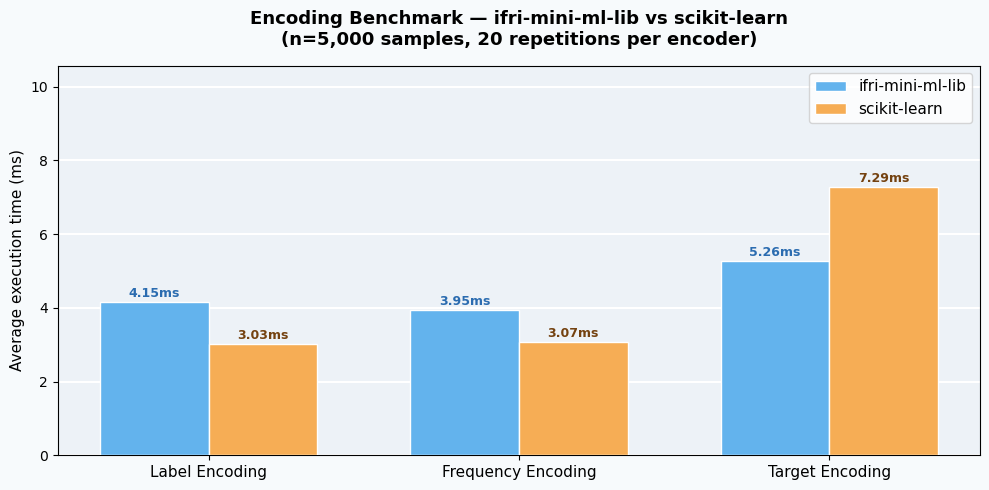

In [50]:
# ── Grouped bar chart ─────────────────────────────────────────
names  = list(timings_ifri.keys())
vals_i = [timings_ifri[n]    for n in names]
vals_s = [timings_sklearn[n] for n in names]
x      = np.arange(len(names))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#EDF2F7')
ax.yaxis.grid(True, color='white', linewidth=1.5, zorder=0)

bars_i = ax.bar(x - width/2, vals_i, width,
                label='ifri-mini-ml-lib', color='#63B3ED', edgecolor='white', zorder=3)
bars_s = ax.bar(x + width/2, vals_s, width,
                label='scikit-learn',     color='#F6AD55', edgecolor='white', zorder=3)

# Annotate bar heights
for bar, v in zip(bars_i, vals_i):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
            f'{v:.2f}ms', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2B6CB0')
for bar, v in zip(bars_s, vals_s):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
            f'{v:.2f}ms', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#744210')

ax.set_xticks(x)
ax.set_xticklabels([n.capitalize() + ' Encoding' for n in names], fontsize=11)
ax.set_ylabel('Average execution time (ms)', fontsize=11)
ax.set_title(
    f'Encoding Benchmark — ifri-mini-ml-lib vs scikit-learn\n'
    f'(n={n:,} samples, {reps} repetitions per encoder)',
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(vals_i), max(vals_s)) * 1.45)
plt.tight_layout()
plt.show()

**How to read this chart:**
- Each pair of bars represents one encoding strategy: **blue** for `ifri-mini-ml-lib`, **orange** for `scikit-learn`.
- The height of each bar is the **mean execution time in milliseconds** over 20 runs.
- A shorter blue bar than its adjacent orange bar indicates that our library is faster for that encoding method.
- Differences in bar height for *Target Encoding* may reflect the overhead of scikit-learn's internal smoothing and cross-validation logic, which `ifri_mini_ml_lib` does not apply by default in this benchmark.

## 5. Real-life Applications

Categorical encoding is a prerequisite in virtually every supervised machine learning pipeline. Below are four domains where the choice of encoding strategy has a measurable impact on model performance:

1. **E-commerce & Recommendation Systems**: Features such as product category, brand name, and seller region are high-cardinality categorical variables. *Frequency encoding* captures how popular a category is, while *target encoding* against purchase probability helps gradient boosting models learn category-level conversion rates without exploding the feature space.

2. **Credit Scoring & Financial Risk**: Loan applications include categorical fields such as employment sector, city of residence, and education level. *Target encoding* against default rates allows models like XGBoost and LightGBM to capture the empirical risk associated with each category — a technique widely used in both Kaggle competitions and production scoring systems.

3. **Healthcare & Clinical Data**: Diagnosis codes (ICD-10), medication names, and hospital department identifiers are categorical variables with thousands of unique values. *Frequency encoding* is often preferred here, as it avoids target leakage in survival analysis pipelines and is compatible with both linear and tree-based models.

4. **Natural Language Processing**: Before the era of word embeddings, token vocabularies were encoded with *label encoding* as a precursor to embedding lookup layers. Today, label encoding remains the standard first step in tokenization pipelines for large language models.

## 6. Limitations and Challenges

Each encoding strategy carries specific failure modes that practitioners must understand before deploying them in production.

### 6.1 Label Encoding — False Ordinality

Assigning integer indices $\{0, 1, 2, \dots, K-1\}$ to unordered categories implicitly imposes a total order that has no semantic meaning. For example, encoding `{red: 0, blue: 1, green: 2}` tells a linear model that `green > blue > red` by a factor of 2, which is entirely fictitious.

- **Vulnerable algorithms**: Linear regression, SVM, neural networks — any model that treats the input as a metric space.
- **Safe algorithms**: Decision Trees, Random Forests, Gradient Boosting — they only use threshold comparisons, not magnitudes.
- **Mitigation**: Use one-hot encoding for algorithms that assume metric input spaces.

---

### 6.2 Frequency Encoding — Collision

If two distinct categories $c_i \neq c_j$ have identical counts ($n_i = n_j$), they receive the same encoded value. The model cannot distinguish between them, effectively merging their predictive signals.

- **Most affected**: Features with near-uniform distributions (e.g., 20 equally probable cities).
- **Mitigation**: Combine frequency encoding with a secondary feature such as label encoding to disambiguate colliding categories.

---

### 6.3 Target Encoding — Data Leakage

Data leakage occurs when information from the test set contaminates the training process. If $\phi_{\text{target}}$ is computed on the entire dataset $\mathcal{D}$ including the test split, then the encoded value of a test sample already incorporates its own target $y_i$:

$$\phi_{\text{target}}(c_k) = \frac{1}{|\mathcal{I}_k|} \sum_{i' \in \mathcal{I}_k} y_{i'} \ni y_i \quad \text{(if } i \text{ is in the test set)}$$

This inflates validation metrics and leads to models that fail to generalize to truly unseen data.

**Mitigation strategies:**
- Always fit the encoder **on the training set only**, then call `transform()` on both train and test sets.
- Use **leave-one-out** or **k-fold cross-validated** target encoding.
- Apply **Laplace smoothing** (smoothing parameter $\lambda > 0$) to reduce variance for rare categories.

## 7. References

- Micci-Barreca, D. (2001). *A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems*. ACM SIGKDD Explorations Newsletter, 3(1), 27-32.
- Prokhorenkova, L., Gusev, G., Vorobev, A., Dorogush, A. V., & Gulin, A. (2018). *CatBoost: unbiased boosting with categorical features*. NeurIPS 2018.
- Preprocessing Categorical Features, Scikit-learn Documentation, https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features
- Target Encoding Done Right, Kaggle Learn, https://www.kaggle.com/code/ryanholbrook/target-encoding
- Categorical Encoding Techniques, Towards Data Science, https://towardsdatascience.com/all-about-categorical-variable-encoding-305f3361fd02